# 2. The mesh and the vertical grid

**What this shows:** what a SCHISM mesh contains, how its resolution relates to the
time step, the property files rompy-schism writes next to it, and how the vertical
grid makes a model 2D or 3D.

**Prerequisites:** [Tutorial 1: Your first SCHISM model](01_first_model.ipynb).

**You will learn:**

- what `hgrid.gr3` holds: nodes, depths, triangles, open and land boundaries
- how to look at the resolution of a mesh and check it against the time step
- which property files (`*.gr3`) SCHISM needs, and how to give spatially varying
  friction
- how `vgrid.in` sets the number of layers, and how to make a 3D vertical grid

**Data used:** `hgrid.gr3`, the mesh of the coast off Perth.

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from rompy.core.data import DataBlob
from rompy.logging import config as logging_config
from rompy_schism.grid import SCHISMGrid

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "02_mesh_and_vertical_grid"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

ASPECT = 1 / np.cos(np.radians(32))  # plot degrees with equal distances at 32°S

## 1. What the mesh contains

A SCHISM mesh, `hgrid.gr3`, lists the nodes (longitude, latitude and depth, positive
down), the elements (triangles here; SCHISM also accepts quadrilaterals) and the
boundary: which nodes form open boundaries and which form land. It is the same format
as ADCIRC's `fort.14`, so meshes made for ADCIRC work too.

`SCHISMGrid` reads it with [pylib](https://github.com/wzhengui/pylibs), SCHISM's
Python library, available as `grid.pylibs_hgrid`.

In [2]:
grid = SCHISMGrid(hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=0.0025)
hgrid = grid.pylibs_hgrid
print(f"{hgrid.np} nodes, {hgrid.ne} elements")
print(Path(DATA_DIR / "hgrid.gr3").read_text().splitlines()[:4])

6790 nodes, 12958 elements
['!grd info:Perth coast, ETOPO 2022, gmsh', '12958 6790', '1 115.00000000 -32.60000000 135.00000000', '2 115.00000000 -31.60000000 205.50000000']


The depth comes from ETOPO 2022. Nodes on the coast can be slightly above sea level
(negative depth); SCHISM wets and dries them as the water level changes.

[Text(0.5, 1.0, 'Rottnest Island and Fremantle'),
 (115.4, 115.8),
 (-32.2, -31.9),
 None]

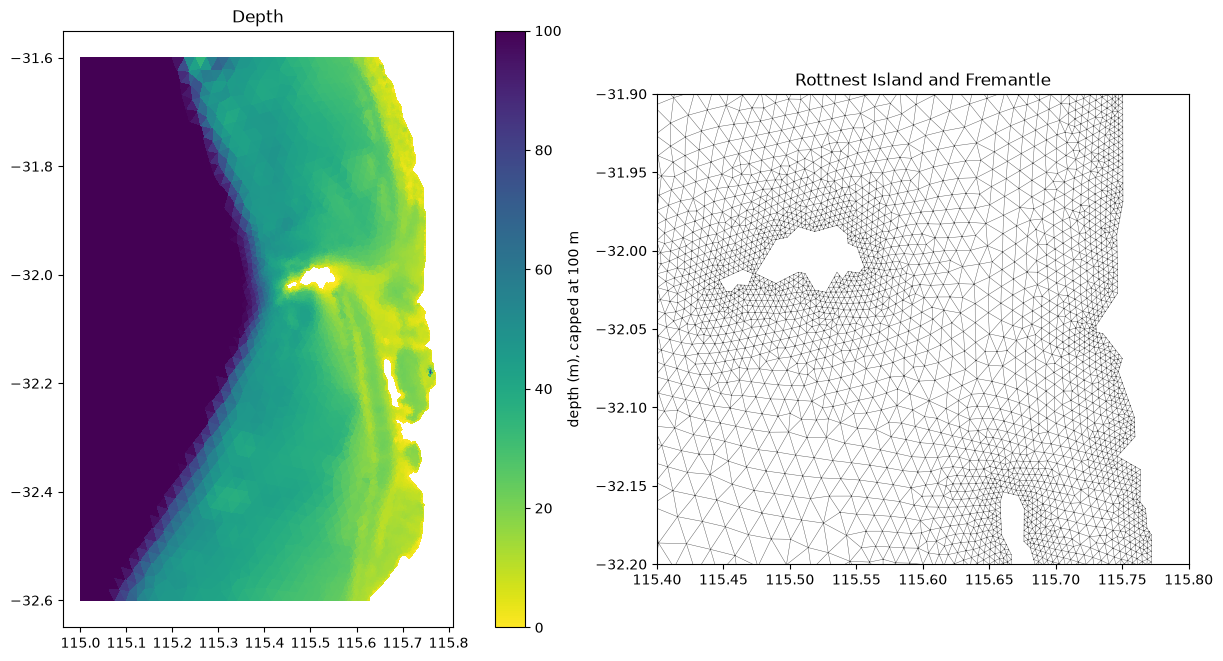

In [3]:
triangulation = mtri.Triangulation(hgrid.x, hgrid.y, hgrid.elnode[:, :3])
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), layout="constrained")
tpc = axes[0].tripcolor(triangulation, hgrid.dp, cmap="viridis_r", vmin=0, vmax=100)
fig.colorbar(tpc, ax=axes[0], label="depth (m), capped at 100 m")
axes[0].set(title="Depth", aspect=ASPECT)
axes[1].triplot(triangulation, color="0.3", linewidth=0.3)
axes[1].set(
    title="Rottnest Island and Fremantle", xlim=(115.4, 115.8), ylim=(-32.2, -31.9),
    aspect=ASPECT,
)

## 2. Resolution

The mesh follows the coast: triangles are about 400 m long near the shore and grow to
about 2.5 km offshore. A useful measure of size is the side of an equilateral
triangle with the same area.

[Text(0.5, 0, 'element size (m)'), Text(0, 0.5, 'elements')]

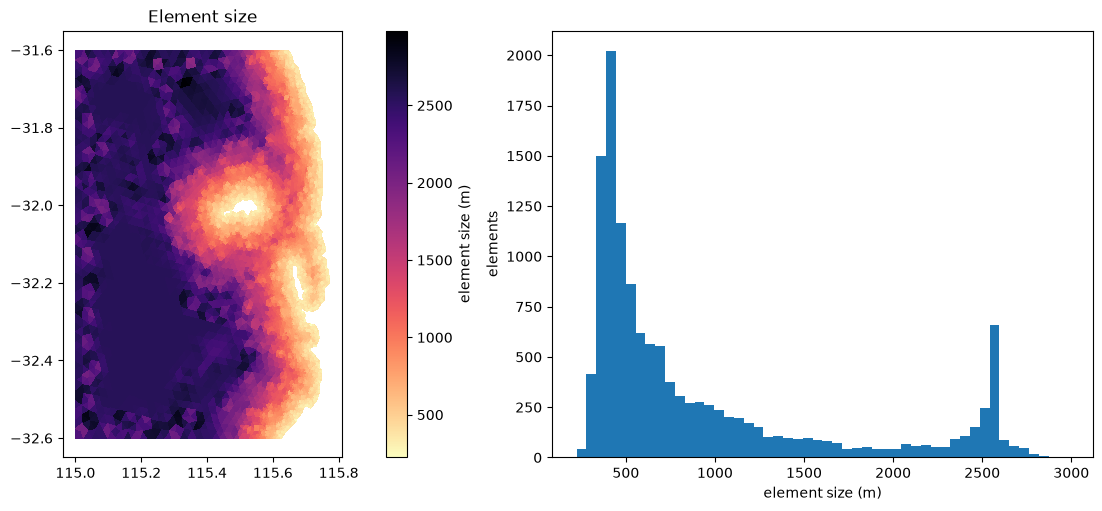

In [4]:
hgrid.compute_area()
metres_per_degree = 111_320 * np.sqrt(np.cos(np.radians(hgrid.y[hgrid.elnode[:, 0]])))
size = np.sqrt(4 * hgrid.area / np.sqrt(3)) * metres_per_degree
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
tpc = axes[0].tripcolor(triangulation, facecolors=size, cmap="magma_r")
fig.colorbar(tpc, ax=axes[0], label="element size (m)")
axes[0].set(title="Element size", aspect=ASPECT)
axes[1].hist(size, bins=50)
axes[1].set(xlabel="element size (m)", ylabel="elements")

SCHISM is semi-implicit, so a time step longer than the explicit stability limit is
fine. Its manual instead asks for a time step long enough to keep numerical diffusion
low: a Courant number $(|u| + \sqrt{gh})\,\Delta t / \Delta x$ above about 0.4. With
`dt = 120` s, every element of this mesh is comfortably above it, so the 2-minute step
of Tutorial 1 suits the mesh. The
[SCHISM manual](https://schism-dev.github.io/schism/master/getting-started/grid-generation.html)
explains the reasoning.

In [5]:
dt = 120.0
depth = np.clip(hgrid.dp[hgrid.elnode[:, :3]].mean(axis=1), 0.1, None)
courant = np.sqrt(9.81 * depth) * dt / size
print(f"Courant number: minimum {courant.min():.2f}, median {np.median(courant):.1f}")

Courant number: minimum 0.28, median 2.2


## 3. Open and land boundaries

The outline of the mesh is split into open boundaries, where the sea continues, and
land boundaries. This mesh has one open boundary (the west, north and south sides)
and four land boundaries: the coast and three islands.

The order matters. `bctides.in` has one entry per open boundary, in the order of
`hgrid.gr3`, and boundary files such as `elev2D.th.nc` list the open boundary nodes in
that order too. rompy-schism writes both from the mesh.

[Text(0.5, 1.0, '1 open boundary with 115 nodes'), None]

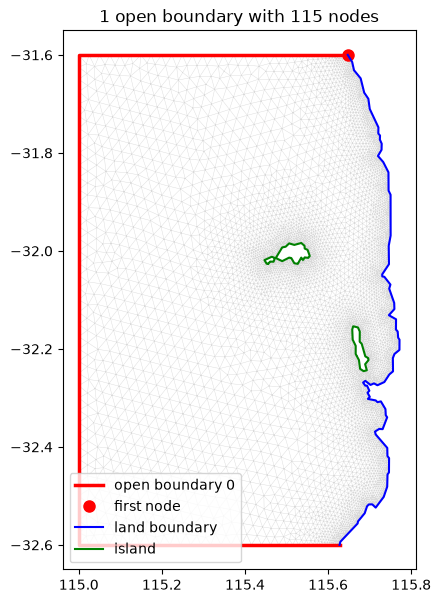

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 7))
ax.triplot(triangulation, color="0.85", linewidth=0.3)
for i, nodes in enumerate(hgrid.iobn):
    ax.plot(hgrid.x[nodes], hgrid.y[nodes], "r", linewidth=2.5, label=f"open boundary {i}")
    ax.plot(hgrid.x[nodes[0]], hgrid.y[nodes[0]], "ro", markersize=8, label="first node")
for nodes, island in zip(hgrid.ilbn, hgrid.island):
    ax.plot(hgrid.x[nodes], hgrid.y[nodes], "b" if not island else "g", linewidth=1.5)
ax.plot([], [], "b", label="land boundary")
ax.plot([], [], "g", label="island")
ax.legend(loc="lower left")
ax.set(title=f"{grid.nob} open boundary with {grid.nobn[0]} nodes", aspect=ASPECT)

## 4. Property files

Besides the mesh, SCHISM reads several files in the same format with one value per
node. rompy-schism writes them from `SCHISMGrid` fields, as a constant unless you give
a file:

| Field | File | Used for |
|---|---|---|
| `drag`, `rough` or `manning` | `drag.gr3`, `rough.gr3` or `manning.gr3` | Bottom friction: drag coefficient, roughness length or Manning's n. One is required |
| `diffmin`, `diffmax` | `diffmin.gr3`, `diffmax.gr3` | Limits of vertical diffusivity, for the turbulence closure in 3D |
| `albedo`, `watertype` | `albedo.gr3`, `watertype.gr3` | Heat exchange with the atmosphere |
| `windrot_geo2proj` | `windrot_geo2proj.gr3` | Rotation between the wind and the mesh coordinates |
| `hgridll`, `hgrid_WWM` | `hgrid.ll`, `hgrid_WWM.gr3` | The mesh in longitude and latitude, and for the WWM wave model (links to `hgrid.gr3` here) |
| `wwmbnd` | `wwmbnd.gr3` | Open boundary flags for WWM |

SCHISM also reads `tvd.prop`, one flag per element for the transport scheme.

In [7]:
grid.get(OUT_DIR / "grid_files")
sorted(p.name for p in (OUT_DIR / "grid_files").iterdir())

['albedo.gr3',
 'diffmax.gr3',
 'diffmin.gr3',
 'drag.gr3',
 'hgrid.gr3',
 'hgrid.ll',
 'hgrid_WWM.gr3',
 'tvd.prop',
 'vgrid.in',
 'watertype.gr3',
 'windrot_geo2proj.gr3',
 'wwmbnd.gr3']

Friction usually varies in space. A property file is written with pylib's
`write_hgrid`, with the values in place of the depths. Here the drag coefficient
rises from 0.0025 offshore to 0.005 in water shallower than 5 m, a common way of
representing rougher nearshore beds. `SCHISMGrid` takes the file as a `DataBlob`.

[Text(0.5, 1.0, 'Spatially varying friction'), None]

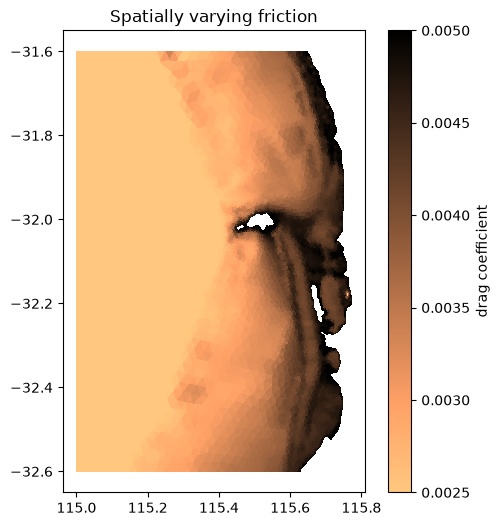

In [8]:
drag = np.interp(hgrid.dp, [5.0, 50.0], [0.005, 0.0025])
drag_file = OUT_DIR / "drag.gr3"
hgrid.write_hgrid(str(drag_file), value=drag)

grid_varying = SCHISMGrid(
    hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"), drag=DataBlob(source=drag_file)
)
fig, ax = plt.subplots(figsize=(6, 6))
tpc = ax.tripcolor(triangulation, drag, cmap="copper_r")
fig.colorbar(tpc, ax=ax, label="drag coefficient")
ax.set(title="Spatially varying friction", aspect=ASPECT)

## 5. The vertical grid

`vgrid.in` sets the layers. A **2D** (depth-averaged) model has a single layer, two
levels: this is what `SCHISMGrid` writes when no vertical grid is given.

In [9]:
print(f"3D: {grid.is_3d}, levels: {grid.nvrt}")
print((OUT_DIR / "grid_files" / "vgrid.in").read_text())

3D: False, levels: 2
2  !ivcor
2 1 1000000.0 !nvrt, kz, h_s 
Z levels
1 -1000000.0
S levels
40.0 0.5 1.0 !h_c, theta_b, theta_f
1 -1.000000
2  0.000000



A **3D** model needs more layers. SCHISM has two kinds of vertical grids:

- **SZ:** terrain-following (sigma) layers, optionally with fixed-depth (Z) levels
  below a transition depth. rompy-schism generates it with `VgridGenerator` or `VGrid`.
- **LSC²:** localised sigma coordinates, where the number of layers varies with depth.
  It is made from the mesh depths with SCHISM's `gen_vqs` tool; give the resulting
  `vgrid.in` to `SCHISMGrid` as a `DataBlob`.

Here, 20 sigma levels. `theta_f` concentrates levels near the surface, `theta_b` also
near the bottom, and `h_c` is the depth above which the levels are evenly spaced.

In [10]:
from rompy_schism.grid import VgridGenerator

grid_3d = SCHISMGrid(
    hgrid=DataBlob(source=DATA_DIR / "hgrid.gr3"),
    vgrid=VgridGenerator(vgrid_type="sz", nvrt=20, h_c=10.0, theta_b=0.5, theta_f=3.0),
    drag=0.0025,
)
print(f"3D: {grid_3d.is_3d}, levels: {grid_3d.nvrt}")

3D: True, levels: 20


The levels along a line west from Fremantle, from the shelf to the continental slope:

[(-1100.0, 10.0),
 Text(0.5, 0, 'longitude'),
 Text(0, 0.5, 'z (m)'),
 Text(0.5, 1.0, 'SZ levels at 32.06°S')]

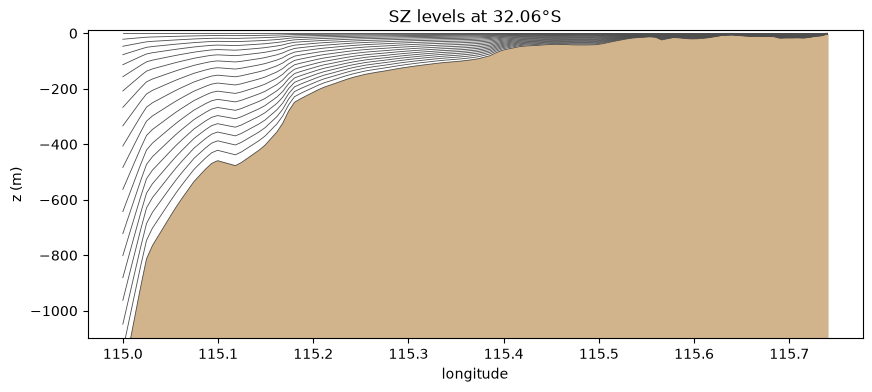

In [11]:
lon = np.linspace(115.0, 115.74, 120)
lat = np.full_like(lon, -32.06)
interpolator = mtri.LinearTriInterpolator(triangulation, hgrid.dp)
section_depth = np.ma.filled(interpolator(lon, lat), np.nan)
zcor = grid_3d.pylibs_vgrid.compute_zcor(section_depth)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lon, zcor, color="0.3", linewidth=0.6)
ax.fill_between(lon, -section_depth, -1200, color="tan")
ax.set(ylim=(-1100, 10), xlabel="longitude", ylabel="z (m)", title="SZ levels at 32.06°S")

## Summary

- `hgrid.gr3` holds the nodes and depths, the elements, and the open and land
  boundaries; open boundaries are numbered in the order of the file.
- Check a mesh's resolution against the time step: SCHISM wants a Courant number
  above about 0.4.
- rompy-schism writes the property files SCHISM needs, as constants or from files.
- `vgrid.in` makes the model 2D (one layer, the default) or 3D.

**Next:** [3. Tides and open boundaries](03_tides_and_open_boundaries.ipynb).